In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [3]:
task = 'Active'
file_path = f'Fit_{task}_early'

np.random.seed(42)
for true_model in ['Linear', 'GainFixed', 'GainModulated']:

    # circonstantial
    if true_model == 'Linear':
        print(f"Skipping true model {true_model} (already fitted)")
        continue

    output_path = Path('ParameterRecovery') / f'{task}_early' / f'From_{true_model}'
    os.makedirs(output_path, exist_ok=True)

    for part in tqdm(range(20)):
        
        # Load real data
        data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
        epochs_file = cwd.parents[0] / data_ref
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            state_train_empirical = lead.STG(epochs_file, tmin=100, tmax=200)
            n_categories = len(list(state_train_empirical.keys()))
            categories = list(range(n_categories))

        # Load parameters estimated on the real data
        if true_model == 'Linear':
            param_path = Path(file_path) / f"LinearModel_part{part}_params"
            truth = lead.model.StratifiedLinear(tau=10, process_noise=0.1, measure_noise=0.1)
            truth.load_params(param_path)
        elif true_model == 'GainFixed':
            param_path = Path(file_path) / f"GainFixedModel_part{part}_params"
            truth = lead.model.StratifiedNonLinear1(tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5, gain=0.1)
            truth.load_params(param_path)
        elif true_model == 'GainModulated':
            param_path = Path(file_path) / f"GainModulatedModel_part{part}_params"
            truth = lead.model.StratifiedGainModulation(tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
            truth.load_params(param_path)

        # Input definition (same for all categories & trials)
        one_input = np.concatenate((np.zeros(60), np.ones(10), np.zeros(180)))
        input_train = {cat: np.stack([one_input for _ in range(state_train_empirical[cat].shape[0])]) for cat in categories}

        # Simulate data from the fitted model
        state_train = truth.measure_simulations(input_series=input_train)

        # Create fake participant id and save its data
        fake_part = 0
        while os.path.exists(output_path / f"SimulatedData_part{fake_part}.npz"):
            fake_part += 1
        save_compatible_state_train = {str(cat): state_train[cat] for cat in categories}
        np.savez_compressed(output_path / f"SimulatedData_part{fake_part}.npz", **save_compatible_state_train)
        truth.save_params(output_path / f"TrueModel_part{fake_part}_params")

        # Re-organize to gather baseline windows together (= whole trials with no stim + baseline of trials with a stim)
        no_stim_sliced = np.concatenate([state_train[0][:, i*50:(i+1)*50] for i in range(5)])
        pre_stim_sliced = np.concatenate([state_train[cat][:, :50] for cat in range(1, n_categories)])
        state_train[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
        input_train[0] = np.zeros_like(state_train[0])
        
        # ---- Fit StratifiedLinear ----
        linear = lead.fitting_tools.clever_fit_linear(state_train = state_train, input_train = input_train, input_start_index=60, input_stop_index=70)
        linear.save_params(output_path / f"LinearModel_part{fake_part}_params")

        # ---- Fit StratifiedGainModul  ----
        gainmodul = lead.fitting_tools.clever_fit_gainmodul(linear_prefitted = linear, state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=60, input_stop_index=70)
        gainmodul.save_params(output_path / f"GainModulatedModel_part{fake_part}_params")

        # ---- Fit StratifiedNonLinear1  ----
        nonlinear = lead.fitting_tools.clever_fit_nonlinear1(linear_prefitted = linear, state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=60, input_stop_index=70)
        nonlinear.save_params(output_path / f"GainFixedModel_part{fake_part}_params")
        

Skipping true model Linear (already fitted)


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

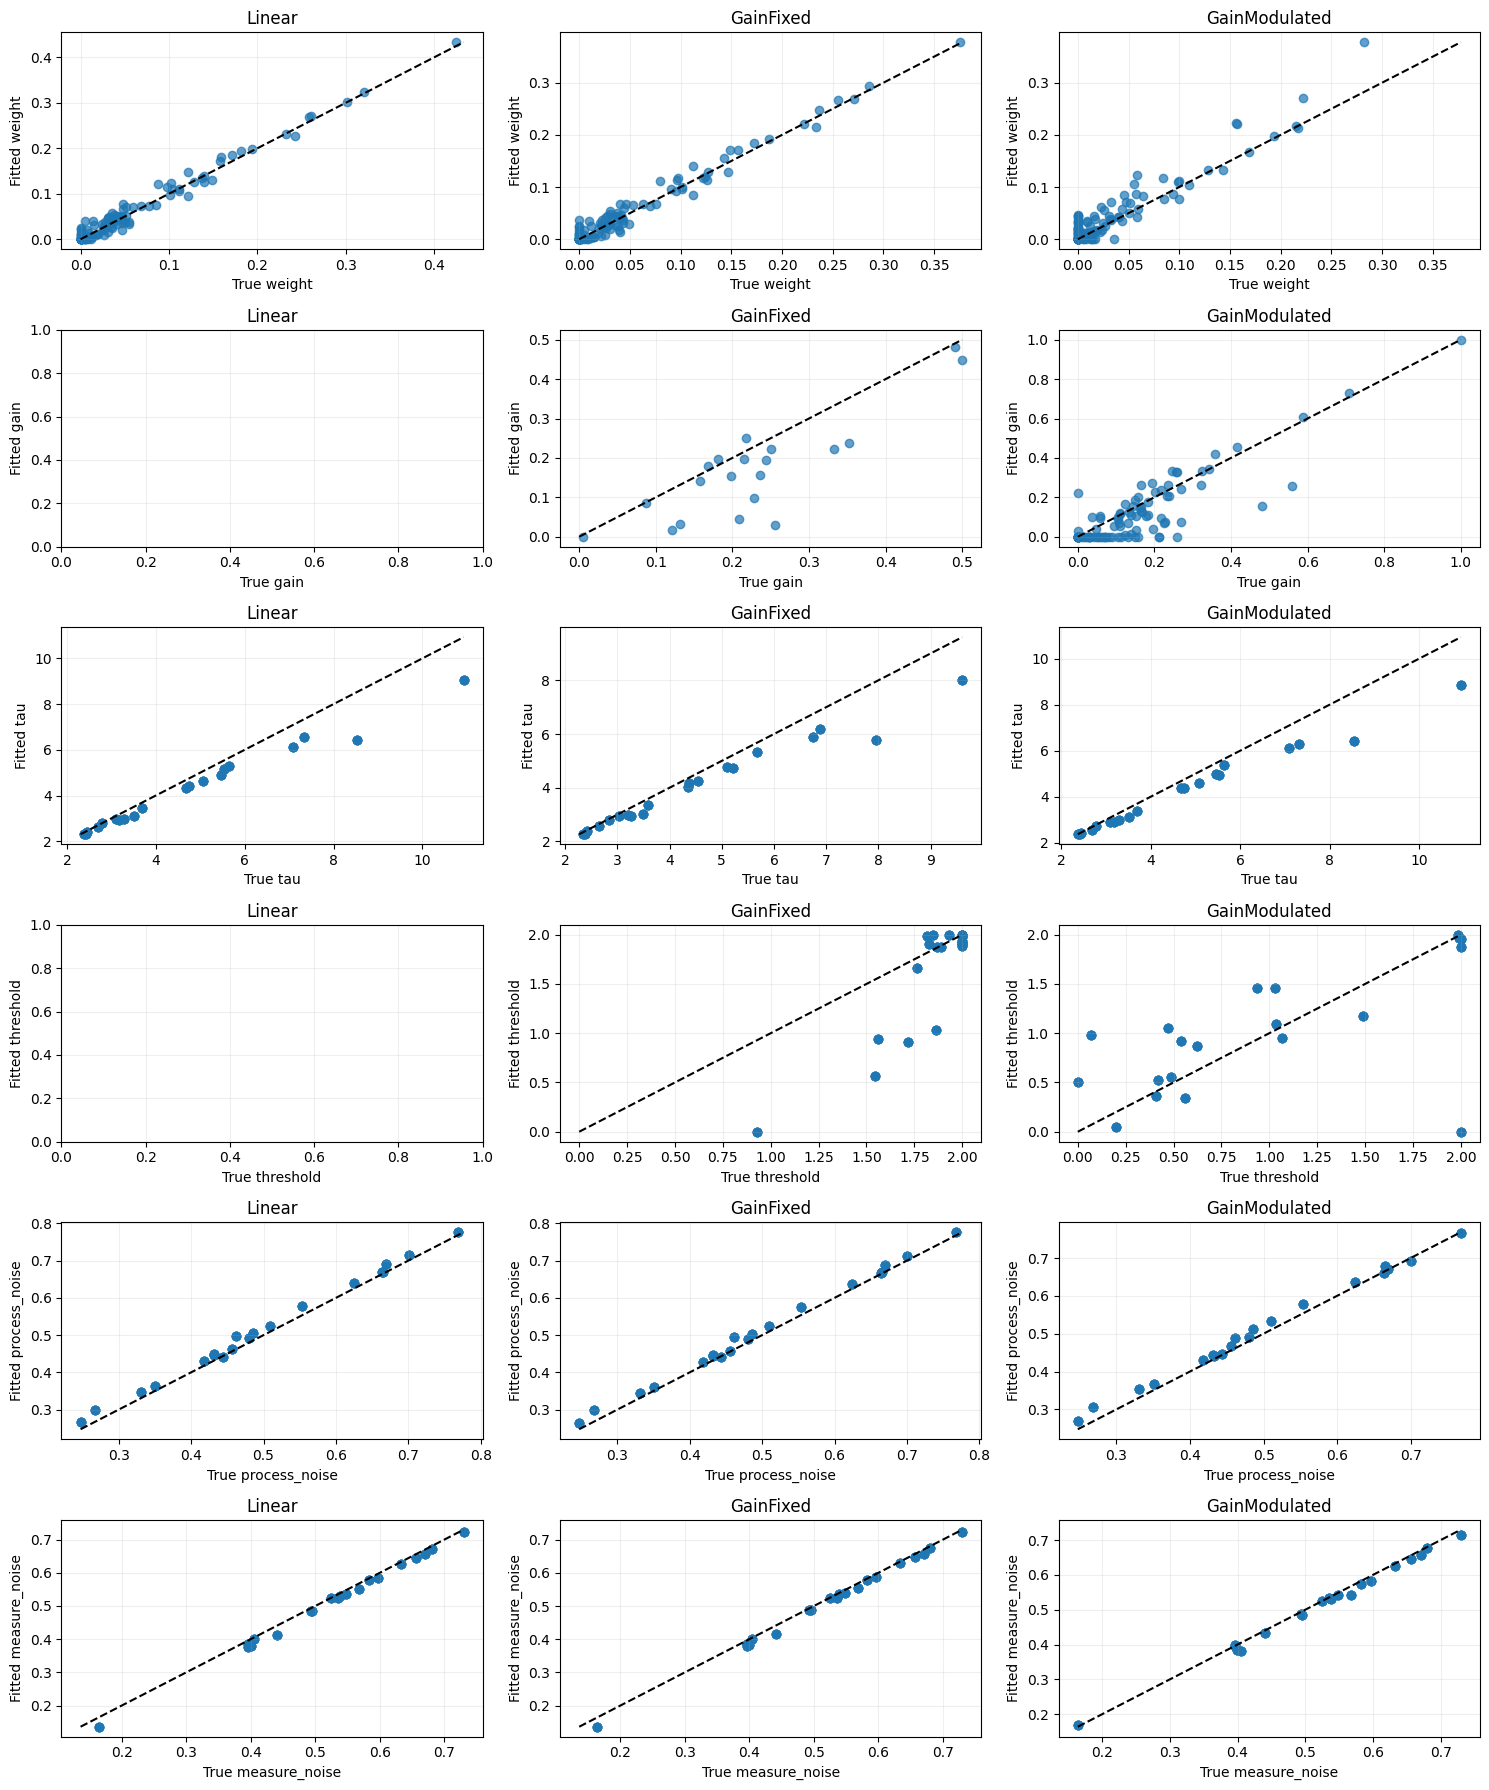

In [11]:
models = {
    'Linear': (lead.model.StratifiedLinear, 'LinearModel'),
    'GainFixed': (lead.model.StratifiedNonLinear1, 'GainFixedModel'),
    'GainModulated': (lead.model.StratifiedGainModulation, 'GainModulatedModel'),
}

parameters = ['weight', 'gain', 'tau', 'threshold', 'process_noise', 'measure_noise']

fig, axes = plt.subplots(len(parameters), 3, figsize=(15, 18))

for row_idx, param in enumerate(parameters):
    for ax, (name, (model_class, file_name)) in zip(axes[row_idx], models.items()):
        true_values, fitted_values = [], []
        folder = Path('ParameterRecovery') / f'{task}_early' / f'From_{name}'

        for part in range(20):
            kwargs = dict(tau=10, process_noise=0.1, measure_noise=0.1)
            if name != 'Linear':
                kwargs.update(threshold=1, sharpness=5)
            if name == 'GainFixed':
                kwargs['gain'] = 0.1

            true_model = model_class(**kwargs)
            fitted_model = model_class(**kwargs)
            true_model.load_params(folder / f'TrueModel_part{part}_params')
            fitted_model.load_params(folder / f'{file_name}_part{part}_params')

            if param == 'weight':
                true_values.extend(getattr(true_model, f'w{i}') for i in range(1, 7))
                fitted_values.extend(getattr(fitted_model, f'w{i}') for i in range(1, 7))
            elif param == 'gain':
                if name == 'GainFixed':
                    true_values.append(getattr(true_model, 'gain'))
                    fitted_values.append(getattr(fitted_model, 'gain'))
                elif name == 'GainModulated':
                    true_values.extend(getattr(true_model, f'g{i}') for i in range(1, 7))
                    fitted_values.extend(getattr(fitted_model, f'g{i}') for i in range(1, 7))
                else:
                    true_values.extend([np.nan] * 6)
                    fitted_values.extend([np.nan] * 6)
            elif param in {'tau', 'process_noise', 'measure_noise'}:
                true_values.extend([getattr(true_model, param)] * 6)
                fitted_values.extend([getattr(fitted_model, param)] * 6)
            elif param == 'threshold':
                if hasattr(true_model, 'threshold'):
                    true_values.extend([getattr(true_model, 'threshold')] * 6)
                    fitted_values.extend([getattr(fitted_model, 'threshold')] * 6)
                else:
                    true_values.extend([np.nan] * 6)
                    fitted_values.extend([np.nan] * 6)

        if true_values and not all(np.isnan(np.asarray(true_values))):
            true_arr = np.asarray(true_values, dtype=float)
            fitted_arr = np.asarray(fitted_values, dtype=float)
            valid = np.isfinite(true_arr) & np.isfinite(fitted_arr)
            if valid.any():
                ax.scatter(true_arr[valid], fitted_arr[valid], alpha=0.7)
                x_min = np.nanmin(np.r_[true_arr[valid], fitted_arr[valid]])
                x_max = np.nanmax(np.r_[true_arr[valid], fitted_arr[valid]])
                if np.isfinite(x_min) and np.isfinite(x_max) and x_max > x_min:
                    ax.plot([x_min, x_max], [x_min, x_max], 'k--')

        ax.set_title(name)
        ax.set_xlabel(f'True {param}')
        ax.set_ylabel(f'Fitted {param}')
        ax.grid(alpha=0.2)

plt.tight_layout()
